<a href="https://colab.research.google.com/github/AlyW8/Data-Science/blob/main/AlysWangUnit7Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Your file on your github needs to be a a .ipynb file with the first four letters of one first name, the first four letters of one last name, and U6proj.

Ex1.

A student named Avy Aguacate Avocado Palta will submit a file named "Avy_AvocU7proj.ipynb", since she normally just goes by Avy, and, when pressed, reports Avocado as her last name. The " _ " after "Avy" serves as the fourth "letter" in her first name.

Ex2.

Army Armadillo will submit a file named "ArmyArmaU7proj.ipynb"

# Unit 7 Project: Polynomials, Splines, and GPs, Oh my!

**Task**:

Two parts:

1. Propose a data set that's compatible with pymc and/or bambi. I must approve your submission before you move on to part 2.

2. Create, analyze, and present any guassian process or approximate GP, degenerate or otherwise (this means glms and b splines are allowed), using pymc within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is), or if must be an actual GP
  - You must document and explain your model selection method. This means you must argue that your model choice (glm, b spline, GP) is better than at least one other choice. You may use either a theoretical or numerical argument.



Guidlines:

- Your data or your model type must be different from any project you've previously done.

- You are allowed to copy and paste any code from the notes, including my answer key (AK), without any reference or citations. Same goes for the course textbook, BAP3.

- This is an individual project. It is fine if you model the same process as a peer, but your raw data **must** be substantially different. "Substantially different" means that I, your instructor, arbitrarily think your data sets are different enough.

- Do not look at other student's code/jupyter notebooks. Copying, or copying and pasting, other students code will result in a failing grade. Also, I will tell all the other teachers I know that you cheated.

- If you want to know what another student did, ask them--any verbal communication about a project is allowed and encouraged. If you want to see a graphic they made, ask them to sketch a picture of it for you by hand.

- Any handwritten communication is also allowed and encouraged, so long as all parties are in the same physical location together. Example: you may sketch out a piece of code while verbally explaining to someone what you did. Do NOT: hand write the code for your entire project, take a picture, and send it to everyone in the course.

- If you use someone's code from outside this course (like from the internet, an AI, or your parent), you must ask me if it is ok, and you must cite them in your work. I don't care all they did was to click your space bar one more time: you tell me, and you cite their contribution. You don't need to tell me about or cite verbal or handwritten communication though.

- You may use a more complicated model--like something from further along in the course--IF I give you permission.

- If you are unsure whether or not something is ok or allowed: ASK BEFORE YOU DO IT.

Faliure to adhere to these guidlines will result in a failing grade.

Tips:

- Try to pick something that you care about, have knowledge of, experience with, or that you find interesting/cool.

- Gather data *before* picking a model or likelihood.

-  Use your best idea now; maybe you can look at the context you used in the previous project, and gather different data from it.

- Choose a data set with lots of columns, and lots of potential interactions between variables. It'll be more fun, and will make model/variable selection more relevant.

- This is not a competition to come up with the fanciest model structure. Find a data set that interests you, and apply the simplest model that captures the patterns in the data.

- Comment heavily, and explain your steps and thought process with text blocks. This is not only requried, it'll also help you understand what you're doing and what you want to do.

- I actually encourge you to use b splines; they work quite well, and trying to determine the location of the knots requires careful thought about the context of the data.

- Its ok to pick a data set for which you don't qute understand the context--so long as you think the context is cool.


In [ ]:
!pip install preliz
!pip install bambi

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb
import seaborn as sns
import graphviz as gv

In [ ]:
counties = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv')


In [ ]:
counties.head()

,name,fips,state,land_area (km^2),area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,...,"industry/Agriculture, forestry, fishing and hunting/payroll","industry/Agriculture, forestry, fishing and hunting/employees",industry/Utilities/payroll,industry/Utilities/employees,industry/Management of companies and enterprises/payroll,industry/Management of companies and enterprises/employees,industry/Industries not classified/payroll,industry/Industries not classified/employees,"industry/Mining, quarrying, and oil and gas extraction/payroll","industry/Mining, quarrying, and oil and gas extraction/employees"
0,cuming county,31039,NE,1477.641638,1488.343176,-96.787366,41.916346,30.5,28.2,48.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lancaster county,31109,NE,2169.252486,2192.120047,-96.688211,40.784132,31.0,25.3,51.0,...,730000.0,111.0,8730000.0,95.0,165117000.0,2024.0,150000.0,3.0,NaN,NaN
2,nuckolls county,31129,NE,1489.645186,1491.363670,-98.047277,40.176383,27.7,22.2,51.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,keith county,31101,NE,2749.531887,2874.204062,-101.657059,41.198294,20.0,25.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,phelps county,31137,NE,1398.048570,1399.695104,-99.414593,40.513105,25.5,26.7,50.3,...,2557000.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
counties.columns.values

array(['name', 'fips', 'state', 'land_area (km^2)', 'area (km^2)',
       'longitude (deg)', 'latitude (deg)', 'noaa/prcp', 'noaa/snow',
       'noaa/temp', 'noaa/altitude', 'noaa/temp-jan', 'noaa/temp-apr',
       'noaa/temp-jul', 'noaa/temp-oct', 'zip-codes',
       'race/non_hispanic_white_alone_male',
       'race/non_hispanic_white_alone_female', 'race/black_alone_male',
       'race/black_alone_female', 'race/asian_alone_male',
       'race/asian_alone_female', 'race/hispanic_male',
       'race/hispanic_female', 'age/0-4', 'age/5-9', 'age/10-14',
       'age/15-19', 'age/20-24', 'age/25-29', 'age/30-34', 'age/35-39',
       'age/40-44', 'age/45-49', 'age/50-54', 'age/55-59', 'age/60-64',
       'age/65-69', 'age/70-74', 'age/75-79', 'age/80-84', 'age/85+',
       'male', 'female', 'population/2010', 'population/2011',
       'population/2012', 'population/2013', 'population/2014',
       'population/2015', 'population/2016', 'population/2017',
       'population/2018', 'populati

In [ ]:
health_columns = [col for col in counties.columns.values if "health" in col]
print(health_columns)

['health/% Fair or Poor Health', 'health/Average Number of Physically Unhealthy Days', 'health/Average Number of Mentally Unhealthy Days', 'health/% Low birthweight', 'health/% Smokers', 'health/% Adults with Obesity', 'health/Food Environment Index', 'health/% Physically Inactive', 'health/% Excessive Drinking', 'health/# Alcohol-Impaired Driving Deaths', 'health/Teen Birth Rate', 'health/% Uninsured', 'health/% With Annual Mammogram', 'health/% Vaccinated', 'health/% Children in Poverty', 'health/80th Percentile Income', 'health/20th Percentile Income', 'health/% Children in Single-Parent Households', 'health/Violent Crime Rate', 'health/Average Daily PM2.5', 'health/% Severe Housing Problems', 'health/% Drive Alone to Work', 'health/% Long Commute - Drives Alone']


In [ ]:
counties_new = counties[[#'name','fips',
                       #  'industry/Manufacturing/payroll',
                         'industry/Construction/payroll',
                       #  'industry/Information/payroll',
                       #  'industry/Finance and insurance/payroll',
                         'health/% Fair or Poor Health',
                       #  'health/80th Percentile Income',
                         'health/Violent Crime Rate',
                         'poverty-rate',
                         'edu/high-school',
                         'avg_income']]
counties_new = counties_new.dropna(ignore_index=True)
counties_new

,industry/Construction/payroll,health/% Fair or Poor Health,health/Violent Crime Rate,poverty-rate,edu/high-school,avg_income
0,8307000.0,14.590580,22.125118,8.9,35.1,58610
1,490580000.0,12.534185,325.955385,10.7,21.5,49889
2,3291000.0,14.655508,105.741121,11.1,31.7,45896
3,18585000.0,13.369139,97.097853,10.0,29.9,52792
4,971000.0,15.194802,110.420980,12.3,35.5,48607
...,...,...,...,...,...,...
2895,114988000.0,13.188439,75.128806,8.0,22.8,64158
2896,896210000.0,19.491660,312.126481,14.0,31.0,48137
2897,39650000.0,12.464001,70.294831,6.8,19.4,78805
2898,85326000.0,12.123954,163.813083,8.5,22.1,68679


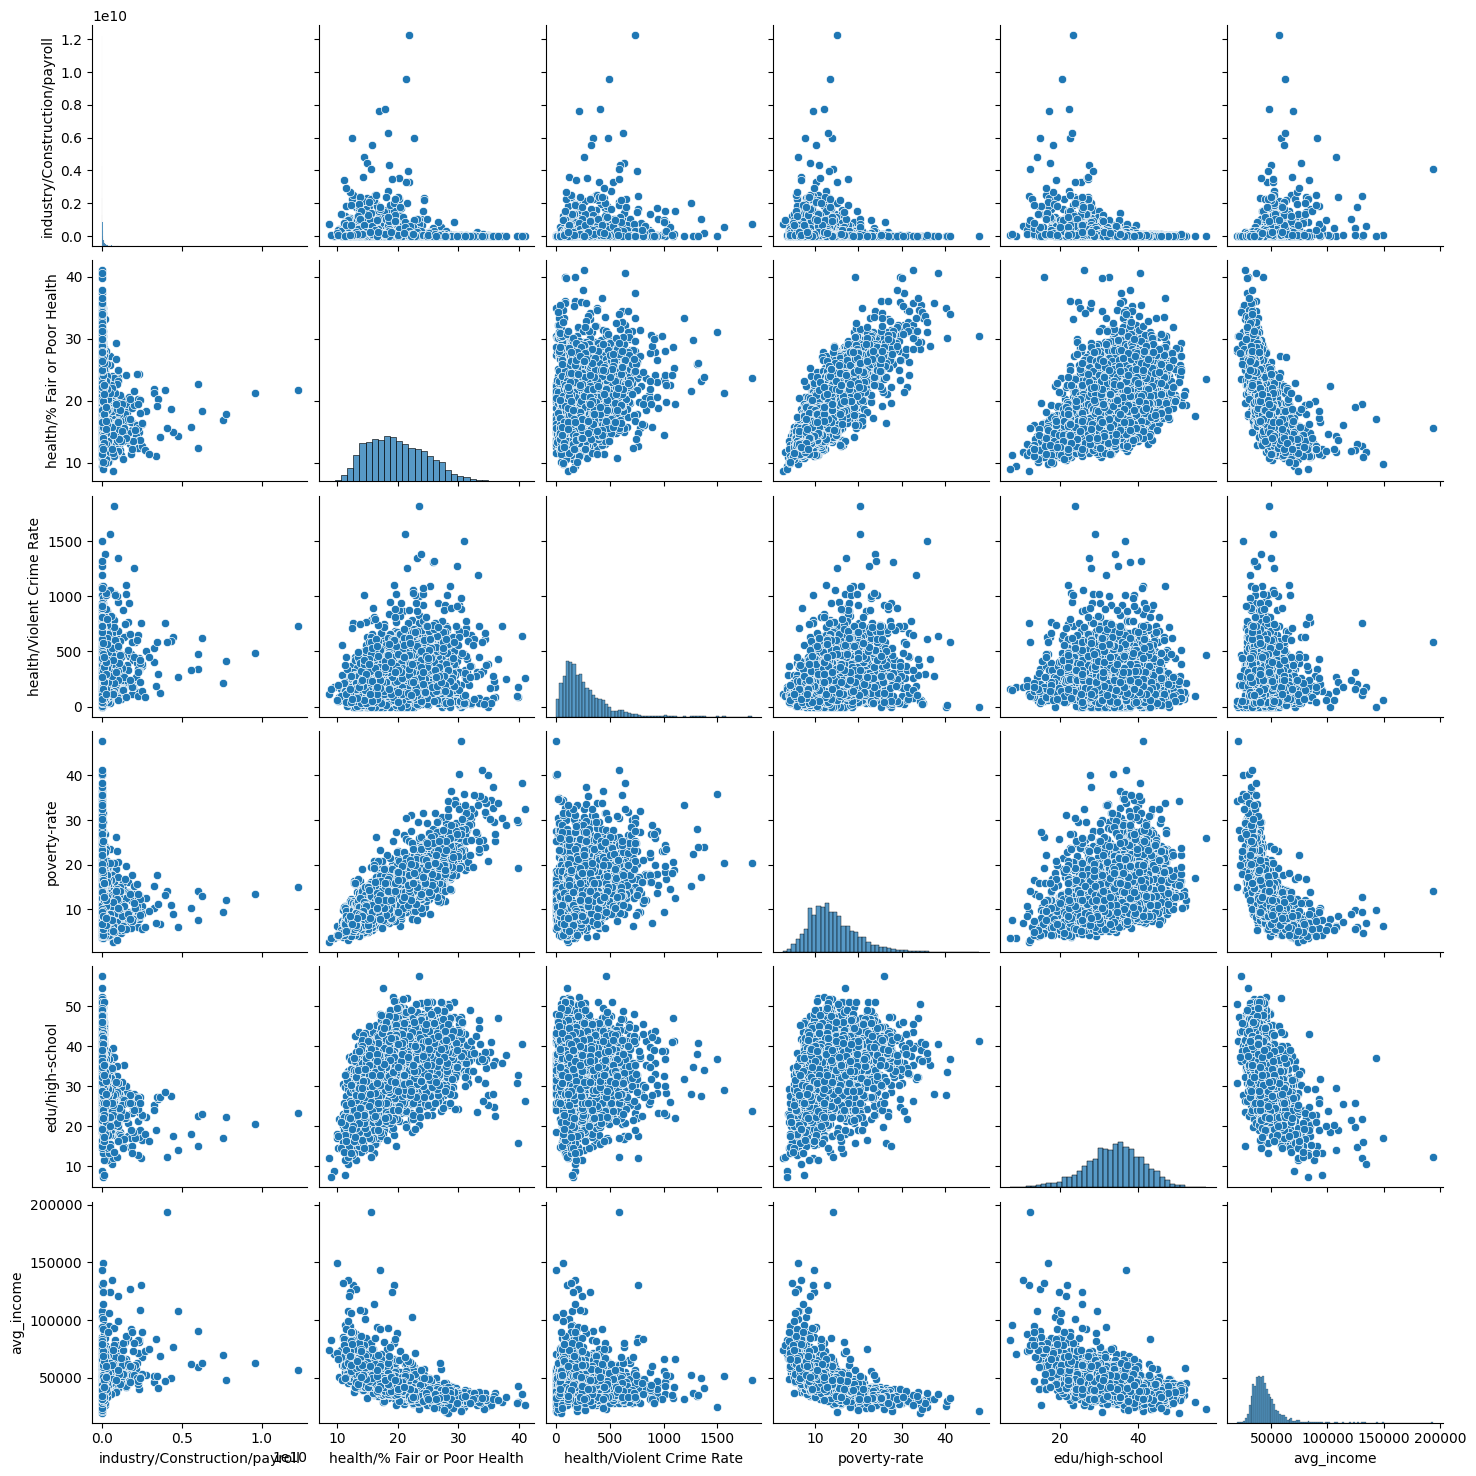

In [ ]:
sns.pairplot(counties_new)

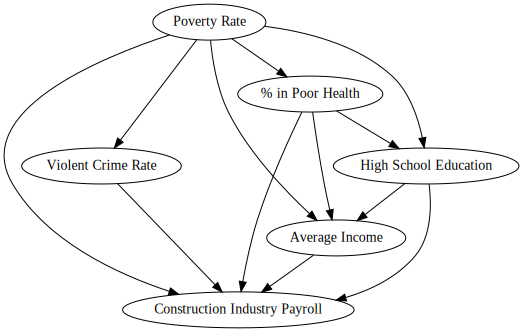

In [ ]:
dag_c = gv.Digraph()

dag_c.node('C','Construction Industry Payroll')
dag_c.node('H','% in Poor Health')
dag_c.node('P','Poverty Rate')
dag_c.node('V','Violent Crime Rate')
#dag.node('N','80th Percentile Income')
dag_c.node('E','High School Education')
dag_c.node('I','Average Income')

dag_c.edges(['EI','PI','HI','PE','PH','PV','HE',
          'HC','VC','PC','EC','IC'])
dag_c

In [ ]:
counties_new = counties_new.rename(columns={'industry/Construction/payroll' : 'construction', "health/Violent Crime Rate":"crime",'health/% Fair or Poor Health':'health','edu/high-school':'education','poverty-rate': 'poverty','avg_income':'income'})

First I'll try all of the variables individually affecting construction.

In [ ]:
model_1 = bmb.Model("construction ~ crime + health + poverty + education + income", counties_new)
idata_1 = model_1.fit(idata_kwargs={"log_likelihood":True})

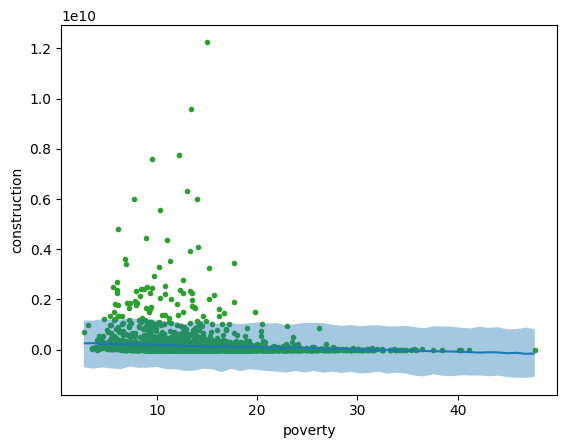

In [ ]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_1, idata_1, "poverty", pps=True)
#raw data
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

I'm removing crime since it seems to have less correlation with the other variables in the pairplot.

In [ ]:
model_nv = bmb.Model("construction ~ crime + health + poverty + education", counties_new)
idata_nv = model_nv.fit(idata_kwargs={"log_likelihood":True})

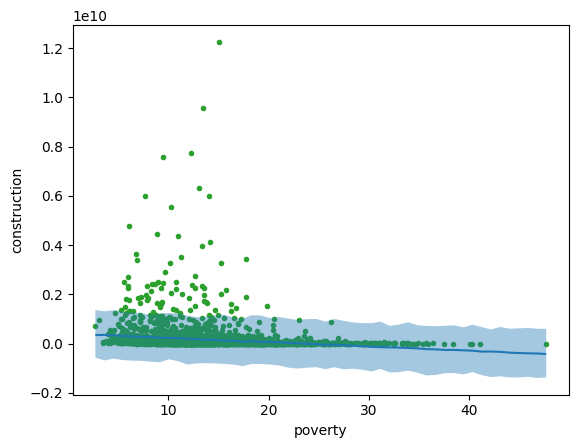

In [ ]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_nv, idata_nv, "poverty", pps=True)
#raw data
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

I'm going to try one with almost all the interactions. It's way too slow with all of them, so I'm removing crime entirely since it didn't seem too relevant from the small difference from when I removed it. I'm almost removing what seem to be less significant interactions from the pairplot, namely: (education|health), (education|poverty)

Taking out both of those 2 seemed to cause some problems with the model (ValueError: There are new groups for the factors ('poverty', 'education', 'income') and 'sample_new_groups' is False.) so I took out (education|health) too.


In [ ]:
model_2 = bmb.Model("construction ~ crime + health + poverty + education + income + (health|poverty) + (income|education) + (crime|poverty) + (income|poverty) + (poverty|education) + (income|health)", counties_new)
idata_2 = model_2.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
bmb.interpret.plot_predictions(model_2, idata_2, "poverty", pps=True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

ValueError: There are new groups for the factors ('poverty', 'education') and 'sample_new_groups' is False.

I can't get these hierarchies to work, so I'll try replacing them with interactions.

In [ ]:
model_3 = bmb.Model("construction ~ crime + health + poverty + education + health:poverty + income:education + crime:poverty + income:poverty", counties_new)
idata_3 = model_3.fit(idata_kwargs={"log_likelihood":True})

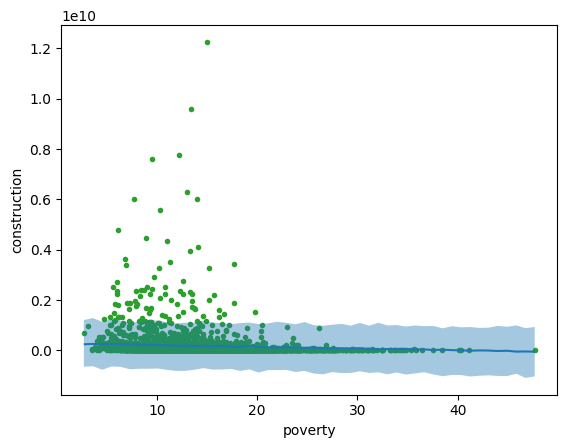

In [ ]:
bmb.interpret.plot_predictions(model_3, idata_3, "poverty", pps=True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

It doesn't look good, but I'll try adding in a few interactions I took out initially to see if it's any better

In [ ]:
model_4 = bmb.Model("construction ~ crime + health + poverty + education + income + health:poverty + income:education + crime:poverty + income:poverty + education:health + education:poverty + income:health", counties_new)
idata_4 = model_3.fit(idata_kwargs={"log_likelihood":True})



---



In [ ]:
counties_new.plot.scatter(x="poverty", y="construction")



---

I want to try some curve fitting for the fun of it. I'm using poverty to estimate construction payroll (or just "construction") because the pair plot seemed the most interesting to try and model.

In [ ]:
model_poly_4 = bmb.Model("construction ~ poly(poverty, degree=4)", counties_new, family="negativebinomial")
idata_poly_4 = model_poly_4.fit()

In [ ]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "poverty", pps=True)
#raw data
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

Looks like I might need a higher degree to better fit the data

In [ ]:
model_poly_6 = bmb.Model("construction ~ poly(poverty, degree=6)", counties_new, family="negativebinomial")
idata_poly_6 = model_poly_6.fit()

In [ ]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_6, idata_poly_6, "poverty", pps=True)
#raw data
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

Raising the degree doesn't seem to be working. I'll try it one more time with a degree 7, and if it still looks terrible, I'll switch to a b-spline.

In [ ]:
model_poly_7 = bmb.Model("construction ~ poly(poverty, degree=7)", counties_new, family="negativebinomial")
idata_poly_7 = model_poly_7.fit()

In [ ]:
bmb.interpret.plot_predictions(model_poly_7, idata_poly_7, "poverty", pps=True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

To be honest, I have no idea why it's doing this. Maybe it's the family? I'll try a gamma distribution

In [ ]:
model_poly_4g = bmb.Model("construction ~ poly(poverty, degree=4)", counties_new, family="gamma")
idata_poly_4g = model_poly_4g.fit()

In [ ]:
bmb.interpret.plot_predictions(model_poly_4g, idata_poly_4g, "poverty", pps=True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

A gamma evidently didn't work any better- much worse, actually. I'm switching over to a b-spline.

In [ ]:
num_knots = 6
knots = np.linspace(0, 48, num_knots+2)[1:-1]
model_spline = bmb.Model("construction ~ bs(poverty, degree=3, knots=knots)", counties_new, family="negativebinomial")
idata_spline = model_spline.fit()

In [ ]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "poverty", pps= True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)

That actually looks a lot better! It's at least modeling the downward trend towards 0, though there's an odd spike after 40 that doesn't seem to be indicated in the observed data. I want to see if I can model the huge hump in the middle, so I'll try increasing the number of knots. I don't know if it'll work the way I want it to though

In [ ]:
num_knots = 8
knots = np.linspace(0, 48, num_knots+2)[1:-1]
model_spline_2 = bmb.Model("construction ~ bs(poverty, degree=4, knots=knots)", counties_new, family="negativebinomial")
idata_spline_2 = model_spline_2.fit()

In [ ]:
bmb.interpret.plot_predictions(model_spline_2, idata_spline_2, "poverty", pps= True)
plt.plot(counties_new.poverty, counties_new.construction, "C2.", zorder=-3)



---



This is my attempt at an HSGP. It keeps disconnecting, saying the runtime is too long, so I gave up on it.

In [ ]:
poverty = counties_new["poverty"].values[:,None]
construction = counties_new["construction"].values

In [ ]:
construction.min()

In [ ]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [ ]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[2.7,47.7], lengthscale_range=[43000, 12256714000], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

In [ ]:
plt.plot(counties_new["poverty"].values, counties_new["construction"].values, "C2.")

In [ ]:
with pm.Model() as model_hsgp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(poverty))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[1596223], c=1743177102.2, cov_func=cov)

    #f is for function, as in the function we use to transform our data
    f = gp.prior('f', X = poverty) # poverty is already reshaped in S49TBykwC3yB
    #prior for the neg binomial
    α = pm.HalfNormal('α', 1)
    #likelihood
    y = pm.NegativeBinomial("y", np.exp(f), α, observed=construction)

    idata_hsgp = pm.sample()

In [ ]:
#set up plot
_, ax = plt.subplots(1, 1, figsize=(12, 4))
#plot raw data
ax.plot(counties_new["poverty"].values, counties_new["construction"].values, "C2.")

#grab posterior
f = az.extract(idata_hsgp, group="posterior", var_names="f")


idx = np.argsort(counties_new["poverty"].values)
#plot samples of the posterior
ax.plot(counties_new["poverty"].values[idx], np.exp(f.values[idx,:100]), alpha=0.25, color="C1")
#plot posterior mean
ax.plot(counties_new["poverty"].values[idx], np.exp(f.values[idx].mean(1)), color="C0", lw=2)

I'll try the HSGP with Bambi to see if it'll work instead.

In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(poverty))
}

priors = {
    "hsgp(poverty, m=1596223, c=1743177102.2)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("construction ~ 0 + hsgp(poverty, m=1596223, c=1743177102.2)", counties_new, family="negativebinomial", priors=priors)
idata_hsb = model_hsb.fit()

In [ ]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["poverty"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(counties_new["poverty"].values, counties_new["rented"].values, "C2.")

It did not work. Let it be known that I tried.